<a href="https://www.kaggle.com/code/mikematician/neural-ode-mnist-gen?scriptVersionId=325485347" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Neural ODE / Continious Normalizing on MNIST-Dataset

In [3]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchdiffeq import odeint_adjoint, odeint
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
import re


# if nvidia gpu available use it
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Nb of Devices: ", torch.cuda.device_count())
    print("Device:",[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Supported archs:", torch.cuda.get_arch_list())

2026-06-08 20:52:32.130773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780951952.362249      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780951952.430750      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780951952.962228      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780951952.962269      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780951952.962271      57 computation_placer.cc:177] computation placer alr

PyTorch: 2.10.0+cpu
CUDA available: False


## 1. Loading MNIST-Dataset

In [49]:
# download test and trainset of mnist via pytorchvision
# dequantization and logit transform to make pixel value bins continoues
lambd = 1e-6
def preprocess(x):
    x = x * 255.0                          # <-- DAS fehlte: zurück auf {0,...,255}
    x = (x + torch.rand_like(x)) / 256.0
    x = lambd + (1 - 2*lambd) * x
    return torch.log(x) - torch.log1p(-x)

# define a transformation from PIL to tensor with normalized pixels
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(preprocess)
])

# download mnist dataset
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# get images
x = train_set.data.float() / 255.0
x = lambd + (1 - 2*lambd) * x
images = torch.log(x) - torch.log1p(-x)

labels = train_set.targets

print()
print(train_set)
print()
print("shape images: ", images.shape)


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Lambda()
           )

shape images:  torch.Size([60000, 28, 28])


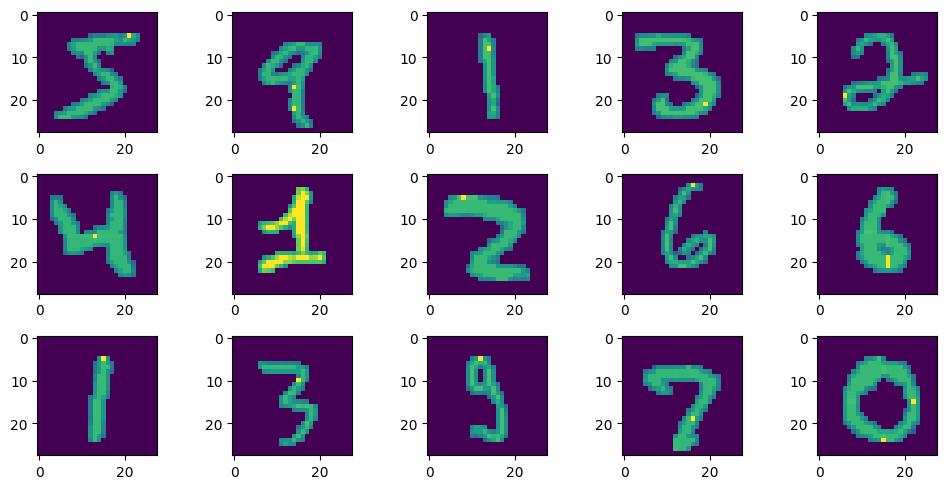

In [53]:
# plot example images
fig, ax = plt.subplots(3, 5, figsize=(10, 5))
ax = ax.flatten()
for i in range(0, 60, 4):
    ax[int(i/4)].imshow(images[i])
fig.tight_layout()

In [54]:
# reduce multidimensional data distribution onto 2D plain with UMAP
reducer = UMAP(n_neighbors=5, n_components=2, min_dist=0.4, metric="euclidean")

# fit reducer onto data
X = images.reshape(len(train_set), -1)
reducer.fit(X)

# make embedding
embedding_train_set = reducer.transform(X).T

(2, 60000)


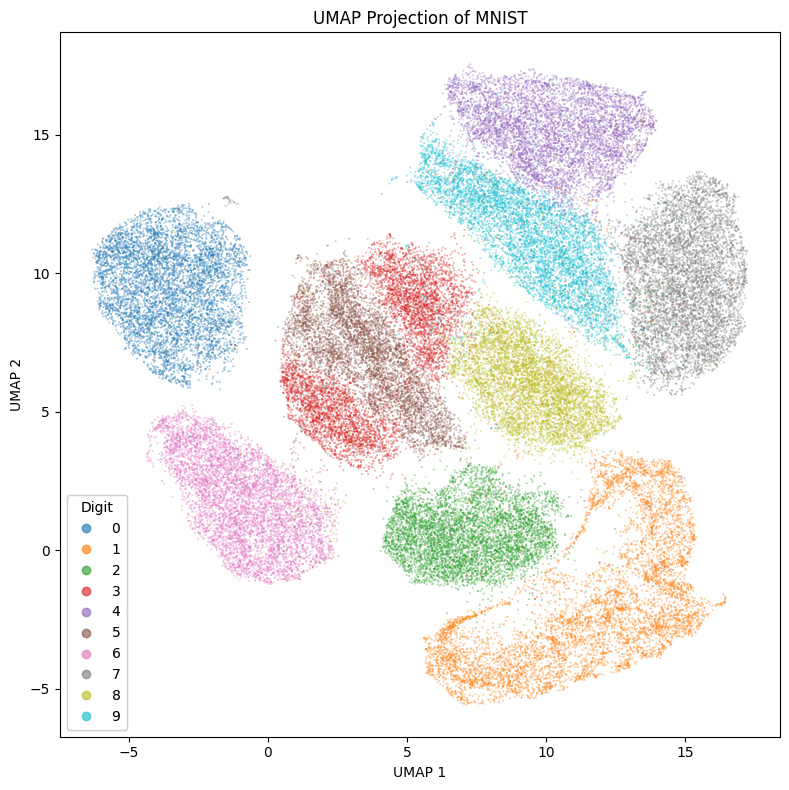

In [52]:
# plot embedding
print(embedding_train_set.shape)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(embedding_train_set[0], embedding_train_set[1], s=0.1, alpha=0.6, c=labels, cmap="tab10")
legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="best")
ax.add_artist(legend)

ax.set_title("UMAP Projection of MNIST")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## 2. Define Model

In [55]:
# injection of time t into CNN
def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -np.log(10000) * torch.arange(half, device=t.device) / half
    )
    args = t[:, None] * freqs[None, :]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class TimeEmbedding(nn.Module):
    def __init__(self, sin_dim=128, t_dim=256):
        super().__init__()
        self.sin_dim = sin_dim
        self.mlp = nn.Sequential(
            nn.Linear(sin_dim, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )

    def forward(self, t):
        h = sinusoidal_embedding(t, self.sin_dim)
        return self.mlp(h)   

In [56]:
# monte carlo estimate of trace for fewer computational complexity
def hutchinson_trace_estimate(dz_dt, z, training=False, eps=None, n_samples=1):
        trace = torch.zeros(z.shape[0], device=z.device)

        # add Frobenius estimate
        frob = torch.zeros(z.shape[0], device=z.device)
    
        for i in range(n_samples):
            v = torch.ones_like(z)
            if eps is None:
                v[torch.rand_like(z) < 0.5] = -1
            else:
                v[eps[i] < 0.5] = -1
            retain = (i < n_samples - 1) or training
            vjp = torch.autograd.grad(dz_dt, z, grad_outputs=v, create_graph=training, retain_graph=retain)[0]
            trace += (vjp * v).flatten(1).sum(1)
            frob  += (vjp ** 2).flatten(1).sum(1)
        return trace / n_samples, frob / n_samples

In [57]:
# Hypothesis: 1. Gamma of FiLM scales Jacobian, therefore also trace -> cat does not affect jacobian of rest
# 2. UNet architecture interweaves grad of Jacobian (Chain Rule mathematically scales trace)

class ResBlock(nn.Module):
    def __init__(self, input_channels, output_channels, t_dim, kernel_size, stride=1, padding=1):
        super().__init__()

        # CNN layers
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=output_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.conv2 = nn.Conv2d(in_channels=output_channels, out_channels=output_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        #self.norm1 = nn.GroupNorm(1, output_channels)
        self.activation = nn.Softplus()
        self.film = nn.Linear(t_dim, 2*output_channels)
        self.skip  = nn.Conv2d(input_channels, output_channels, 1) if input_channels != output_channels else nn.Identity()

    def forward(self, t_emb, z):
        residual = self.skip(z)
        
        # Conv layer
        z = self.conv1(z)
        z = self.activation(z)

        # FiLM injection of time
        beta, gamma = self.film(t_emb).chunk(2, -1)
        z = (1+gamma[:, :, None, None]) * z + beta[:, :, None, None]

        # Conv layer
        z = self.conv2(z)
        
        # activation
        z = residual + z
        return self.activation(z)    


class Sampling(nn.Module):
    def __init__(self,  channels, kernelsize_sampling=None, kernelsize_conv=None, upscale=None, upsampling=False):
        super().__init__()
        if not upsampling:
            self.sampling = nn.AvgPool2d(kernel_size=kernelsize_sampling)
            self.conv = nn.Identity()
        else:
            self.sampling = nn.Upsample(scale_factor=upscale)
            self.conv = nn.Conv2d(channels, channels, kernel_size=kernelsize_conv, padding=1)

    def forward(self, z):
        z = self.sampling(z)
        return self.conv(z)


class CNFResBlock(nn.Module):
    def __init__(self, channel, nb_filters, kernelsize, sin_dim=64, t_dim=128):
        super().__init__()
        # epsilon for hutchinson estimator (here to get less stochasity, because addaptive solver can have problems)
        self.eps = None

        # track NFE
        self.nfe = 0

        # store dimension of FiLM embedding dimension
        self.t_dim = t_dim
        self.sin_dim = sin_dim
        self.time_embedding = TimeEmbedding(sin_dim=self.sin_dim, t_dim=self.t_dim)

        # ResNet layers
        self.resblock1 = ResBlock(channel, nb_filters, self.t_dim, kernel_size=kernelsize, padding=1, stride=1)
        self.downsampling = Sampling(nb_filters, 2)
        self.resblock2 = ResBlock(nb_filters, nb_filters, self.t_dim, kernel_size=kernelsize, padding=1, stride=1)
        self.upsampling = Sampling(nb_filters, kernelsize_conv=kernelsize, upscale=2, upsampling=True)
        self.resblock3 = ResBlock(nb_filters, channel, self.t_dim, kernel_size=kernelsize, padding=1, stride=1)
        self.outconv = nn.Conv2d(in_channels=channel, out_channels=channel, kernel_size=kernelsize, stride=1, padding=1)

    def sample_eps(self, y):
        self.eps = torch.rand_like(y)

    def forward(self, t, state):
        self.nfe += 1
        y, log_p = state
        t_batch = t.unsqueeze(0).expand(y.shape[0])
        t_emb = self.time_embedding(t_batch)

        # calculate divergence/trace
        with torch.enable_grad():
            y = y.requires_grad_(True)
            # ResNet
            dy_dt = self.resblock1(t_emb, y)
            skip = dy_dt
            dy_dt = self.downsampling(dy_dt)
            dy_dt = self.resblock2(t_emb, dy_dt)
            dy_dt = self.upsampling(dy_dt)
            dy_dt = dy_dt + skip
            dy_dt = self.resblock3(t_emb, dy_dt)
            dy_dt = self.outconv(dy_dt)

            # hurchinson trace estimation
            grad_trace, _ = hutchinson_trace_estimate(dy_dt, y, training=self.training, eps=self.eps, n_samples=1)
        
        return (dy_dt, -grad_trace)

In [58]:
# alternative Architecture (from FFJORD Paper and RNODE Paper)

class SingleFlow(nn.Module):
    def __init__(self, input_channel):
        super().__init__()
        # Flow layers
        self.conv1 = nn.Conv2d(in_channels=input_channel+1, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64+1, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64+1, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128+1, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.transconv1 = nn.ConvTranspose2d(in_channels=128+1, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.transconv2 = nn.ConvTranspose2d(in_channels=128+1, out_channels=64, kernel_size=4, stride=2, padding=1)
        self.transconv3 = nn.ConvTranspose2d(in_channels=64+1, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.transconv4 = nn.ConvTranspose2d(in_channels=64+1, out_channels=input_channel, kernel_size=4, stride=2, padding=1)
        self.activation = nn.Softplus()

    def _tc(self, y, t):
        # concatenate t as extra channel
        return torch.cat([y, t.view(-1,1,1,1).expand(y.shape[0],1,y.shape[2],y.shape[3])], dim=1)

    def forward(self, t, y):
        # CNN
        y = self.conv1(self._tc(y, t))
        y = self.activation(y)
        y = self.conv2(self._tc(y, t))
        y = self.activation(y)
        y = self.conv3(self._tc(y, t))
        y = self.activation(y)
        y = self.conv4(self._tc(y, t))
        y = self.activation(y)
        y = self.transconv1(self._tc(y, t))
        y = self.activation(y)
        y = self.transconv2(self._tc(y, t))
        y = self.activation(y)
        y = self.transconv3(self._tc(y, t))
        y = self.activation(y)
        y = self.transconv4(self._tc(y, t))
        return y


class RNODE(nn.Module):
    def __init__(self, nb_samples=None):
        super().__init__()
        # epsilon for hutchinson estimator (here to get less stochasity, because addaptive solver can have problems)
        self.nb_samples = nb_samples if nb_samples is not None else 1
        self.eps = None

        # track NFE
        self.nfe = 0

        # RNODE Net
        self.net = SingleFlow(1)

    def sample_eps(self, y):
        self.eps = torch.rand(self.nb_samples, *y.shape, device=y.device)

    def forward(self, t, state):
        self.nfe += 1
        y, log_p, E, n = state
        
        # calculate divergence/trace
        with torch.enable_grad():
            y = y.requires_grad_(True)
            dy_dt = self.net(t, y)

            # hurchinson trace estimation and frobenius vjp estimate
            grad_trace, frob_norm = hutchinson_trace_estimate(dy_dt, y, training=self.training, eps=self.eps, n_samples=self.nb_samples)

            # kinetic Energy for Benamou-Brenier Optimal transport maps Regularization
            kinetic = (dy_dt ** 2).flatten(1).sum(1)  

        return (dy_dt, -grad_trace, -kinetic, -frob_norm)


## 3. Training Model

In [59]:
# train step function for Neural ODEs
def make_train_step(model, optimizer, frob_reg, kinetic_reg, grad_clipping, ode_solver, rtol, atol, dim_data, device):
    # define prior
    prior = torch.distributions.Independent(torch.distributions.Normal(torch.zeros(dim_data, device=device), torch.ones(dim_data, device=device)), 1)

    # training function that gets created
    def train_step(y_end, t_0, t_end, stepsize, verbose=False):
        optimizer.zero_grad()
        model.train()

        # calculate ODE Backward to use MLE on Gauss distr with connection to datapoints
        batch_size = y_end.shape[0]
        init_state = (y_end, torch.zeros(batch_size, device=y_end.device), torch.zeros(batch_size, device=y_end.device), torch.zeros(batch_size, device=y_end.device))

        # set epsilon for hutchinson trace estimate
        model.sample_eps(y_end)
        
        # calculate adjoint
        model.nfe = 0
        y_states, delta_probs, kinetic_energies, frob_norms = odeint_adjoint(model, init_state, torch.tensor([t_end, t_0], dtype=torch.float32, device=device), rtol=rtol, atol=atol, method=ode_solver)#, options={"step_size": stepsize})
        y_0 = y_states[-1]
        delta_prob = delta_probs[-1]
        kinetic_energy = kinetic_energies[-1]
        frob_norm = frob_norms[-1]

        # calculate loss (MLE)
        y_0_prob = prior.log_prob(y_0.flatten(1))
        log_p = y_0_prob - delta_prob

        # Adding Regularizations
        loss = -log_p.mean() + kinetic_reg * kinetic_energy.mean() + frob_reg * frob_norm.mean()
        
        # calculate gradient
        loss.backward()

        total_norm = sum(p.grad.norm().item()**2 for p in model.parameters() if p.grad is not None)**0.5
        
        # verbose while training
        if verbose:
            print("=== Useful Statistics ===")
            print(f"prior term: {y_0_prob.mean().item():.7f}")
            print(f"delta_prob: {delta_prob.mean().item():.7f}")
            print(f"kinetic_energy: {kinetic_energy.mean().item():.7f}, regularized: {kinetic_reg*kinetic_energy.mean().item():.7f}")
            print(f"frob_norm: {frob_norm.mean().item():.7f}, regularized: {frob_reg*frob_norm.mean().item():.7f}")
            print(f"NFE: {model.nfe}")
            print(f"grad norm: {total_norm:.7f}")
            print("=== Total Loss ===")
            print(f"{loss.mean().item():.7f}")
            print()

        # save trainhistory after every batch
        with open("full_train_statistics.txt", "a") as h:
            h.write("=== Useful Statistics ===\n")
            h.write(f"prior term: {y_0_prob.mean().item():.7f}\n")
            h.write(f"delta_prob: {delta_prob.mean().item():.7f}\n")
            h.write(f"kinetic_energy: {kinetic_energy.mean().item():.7f}, regularized: {kinetic_reg*kinetic_energy.mean().item():.7f}\n")
            h.write(f"frob_norm: {frob_norm.mean().item():.7f}, regularized: {frob_reg*frob_norm.mean().item():.7f}\n")
            h.write(f"NFE: {model.nfe}\n")
            h.write(f"grad norm: {total_norm:.7f}\n")
            h.write("=== Total Loss ===\n")
            h.write(f"{loss.mean().item():.7f}\n")
            h.write("\n")
        
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clipping)

        # optimization and scheduler
        optimizer.step()

        return loss.item()
    
    return train_step

In [60]:
# training parameters
epochs = 15
lr = 1e-4
t_start = 0
t_end = 1
stepsize = 0.2
batch_size = 512
gradient_clip = 8
hutchinson_samples = 3
reg_kin  = 1e-2   # Benamou-Brenier
reg_frob = 1    # Frobenius

# model param
dim_features = 28*28
channel = None
nb_filters = None
kernelsize = None

# init model
#model = CNFResBlock(channel=channel, nb_filters=nb_filters, kernelsize=kernelsize).to(device)
model = RNODE(nb_samples=hutchinson_samples).to(device)

# define ODE Solver
solver = "dopri5"
rtol = 5e-3
atol = 5e-3

# define an optimizer
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

# define lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.7)

# show model summary
#summary(model, input_size=(batch_size, input_dim))

In [ ]:
# Turn Datasets into Dataloader
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# create training function
training_step = make_train_step(model, optimizer, reg_frob, reg_kin, gradient_clip, solver, rtol=rtol, atol=atol, dim_data=dim_features, device=device)

# Training Loop
train_history = []
for e in range(epochs):
    print(f"\n========== Epoch: {e+1} ===========")

    with open("train_history.txt", "a") as f:
            f.write(f"epoch: {e+1}\n")
    
    batch_loss = []
    for i, (image_batch, _) in enumerate(train_loader, 1):
        #print(f"Batch: {i}")
        image_batch = image_batch.to(device)

        # information only some epochs
        verbose=False
        if (e+1)%2==0 or e+1==1:
            verbose=True

        # perform a train step
        loss_b = training_step(image_batch, t_start, t_end, stepsize, verbose=verbose)
        batch_loss.append(loss_b)

        # save trainhistory after every batch
        with open("train_history.txt", "a") as f:
            f.write(f"batch: {i+1}\n")
            f.write(f"{loss_b}")
    
    # calculate loss per epoch
    loss_e = np.array(batch_loss).mean()

    # save trainhistory after every batch
    with open("train_history.txt", "a") as f:
        f.write(f"epoch loss: {loss_e}\n")
        f.write(f"Learning Rate: {optimizer.param_groups[0]['lr']}\n")


    # learning rate scheduler
    scheduler.step(loss_e)
    
    # training statistics
    train_history.append(loss_e)
    print(f"Loss: {loss_e}, Learning Rate: {optimizer.param_groups[0]['lr']}")

    # Model Checkpoint
    if (e+1) % 2 == 0:
        torch.save(model.state_dict(), f"cnf_checkpoint_epoch{e+1}.pt")
        print(f"Checkpoint saved (epoch {e+1})")

## 4. Evaluation

In [ ]:
def load_train_history(filepath):
    train_history = []
    with open(filepath, "r") as f:
        content = f.read()
    
    parts = content.split("epoch loss:")
    for part in parts[1:]:
        loss = float(part.split()[0])        
        train_history.append(loss)
    
    return train_history

In [43]:
# load model and train history
model.load_state_dict(torch.load("/kaggle/input/models/mikematician/reg2/pytorch/default/1/cnf_checkpoint_epoch8.pt", map_location=device))
train_history = load_train_history("/kaggle/input/models/mikematician/reg2/pytorch/default/1/train_history.txt")

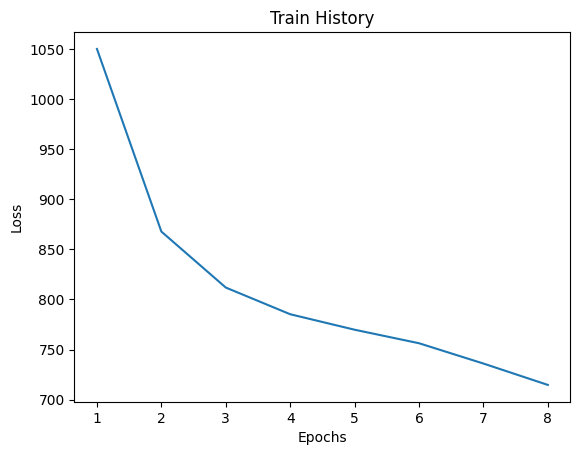

In [16]:
# Train Loss
plt.figure()
plt.plot(range(1, len(train_history)+1), train_history)
plt.title("Train History")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

In [17]:
# Sample Function
@torch.no_grad()
def sample(model, num_samples, t_0, t_end, ode_solver, stepsize, device, rtol, atol, shape=(1, 28, 28)):
    model.eval()
    
    y_0 = torch.randn(num_samples, *shape, device=device)
    # set epsilon for hutchinson trace estimate
    model.sample_eps(y_0)
    init_state = (y_0, torch.zeros(num_samples, device=device), torch.zeros(num_samples, device=device), torch.zeros(num_samples, device=device))
    y_state, _, _, _ = odeint(model, init_state, torch.tensor([t_0, t_end], dtype=torch.float32, device=device), rtol=rtol, method=ode_solver, options={"step_size": stepsize})
    y_end = y_state[-1]
    
    return y_end, y_0

In [44]:
nb_samples = 100
generated_images , gaussian_noise = sample(model, nb_samples, t_start, t_end, solver, stepsize, device, rtol=rtol, atol=atol)

# convert to cpu
generated_images_cpu = generated_images.cpu()
gaussian_noise_cpu = gaussian_noise.cpu()

/usr/local/lib/python3.12/dist-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Dopri5Solver: Unexpected arguments {'step_size': 0.2}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


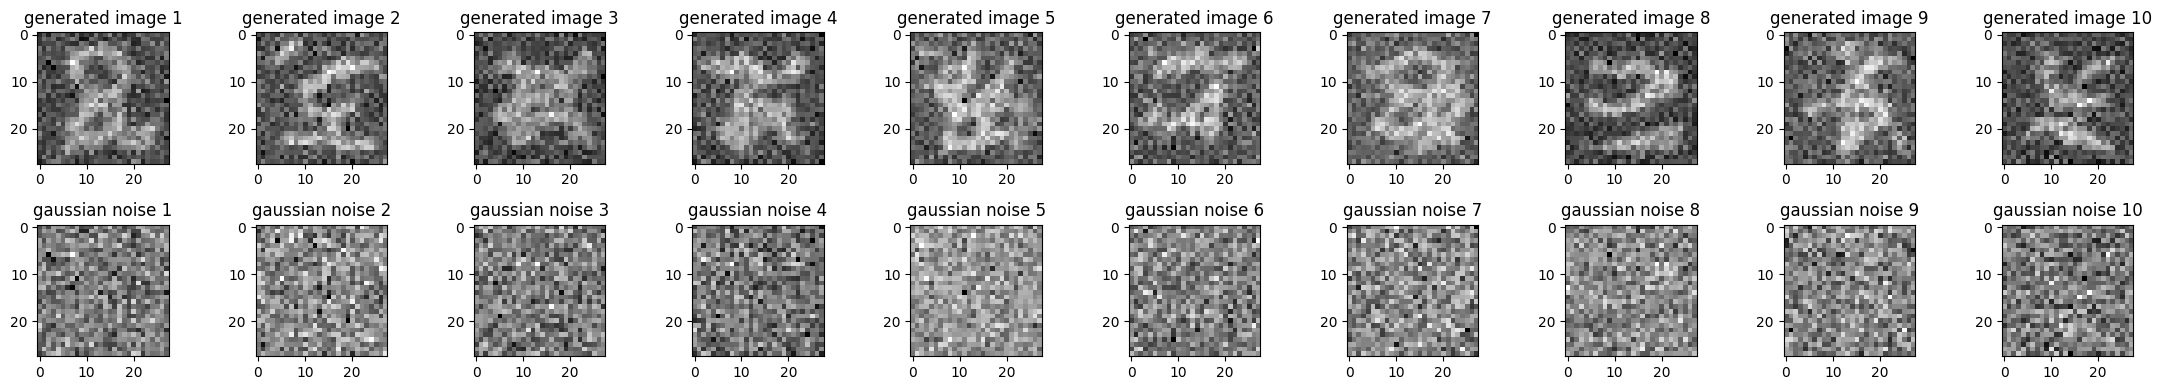

In [45]:
# plot example images
nb_plots = 10

fig, ax = plt.subplots(2, nb_plots, figsize=(2*nb_plots+2, 4))
ax = ax.flatten()
for i in range(0, nb_plots):
    ax[i].imshow(generated_images_cpu[i].squeeze(), cmap="gray")
    ax[i].set_title(f"generated image {i+1}")
    ax[i+nb_plots].imshow(gaussian_noise_cpu[i].squeeze(), cmap="gray")
    ax[i+nb_plots].set_title(f"gaussian noise {i+1}")
fig.tight_layout()


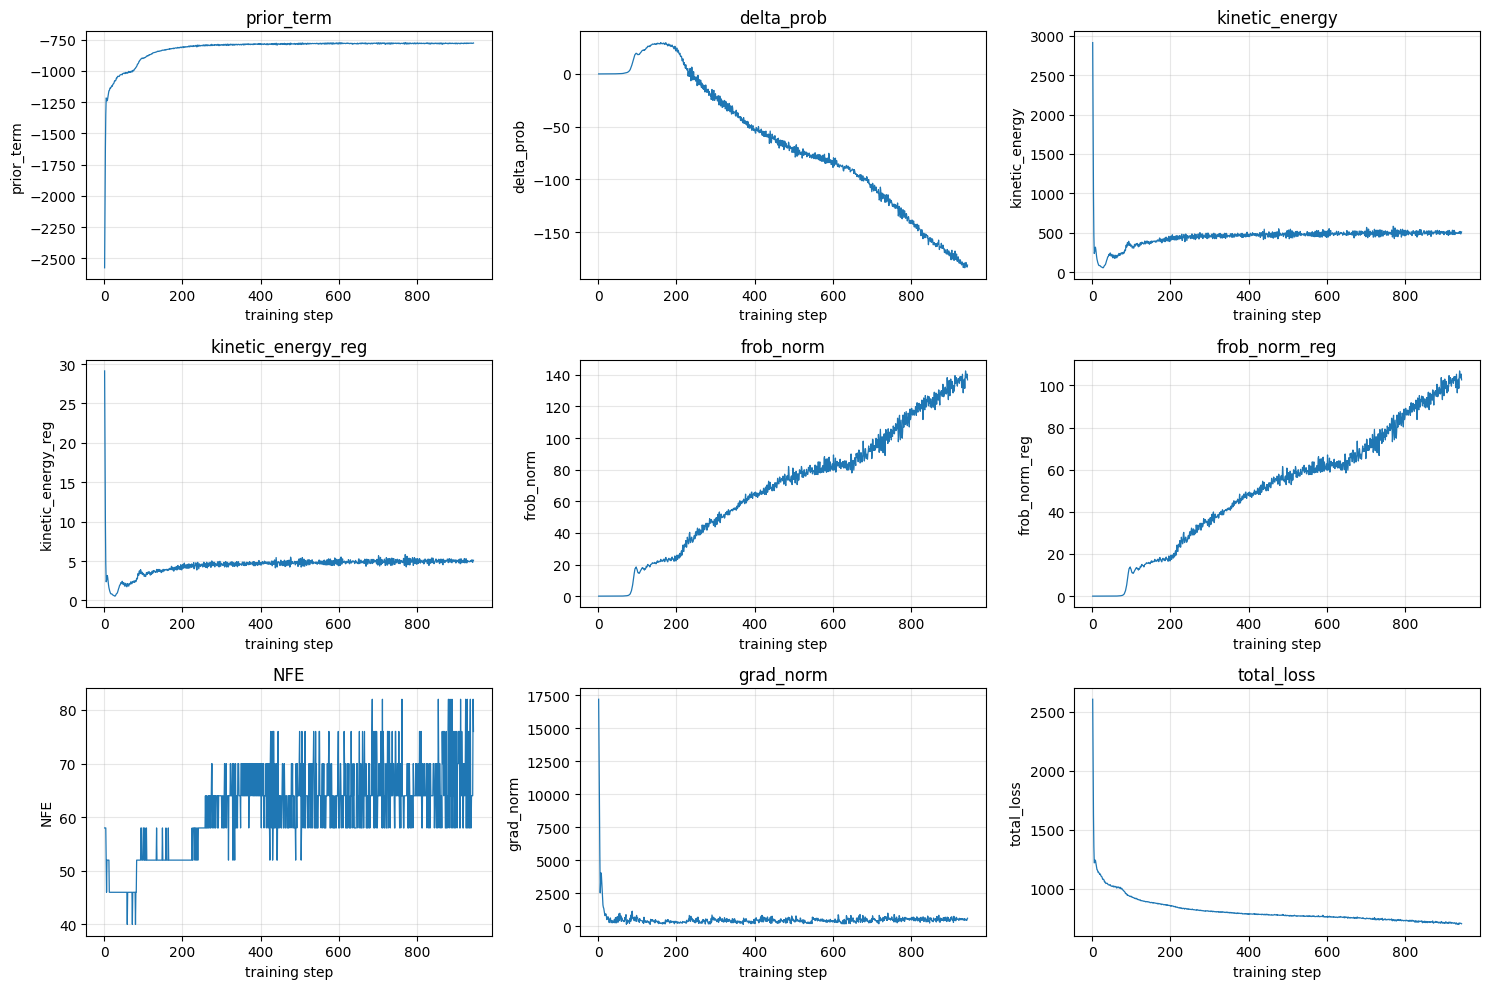

In [46]:
PATH = "/kaggle/input/models/mikematician/reg2/pytorch/default/1/full_train_statistics.txt"
 
with open(PATH) as f:
    text = f.read()
 
blocks = text.split("=== Useful Statistics ===")[1:]
 
def grab(pattern, s):
    m = re.search(pattern, s)
    return float(m.group(1)) if m else float("nan")
 
# metrics
metrics = {
    "prior_term":              r"prior term:\s*(-?[\d.]+)",
    "delta_prob":              r"delta_prob:\s*(-?[\d.eE+]+)",
    "kinetic_energy":          r"kinetic_energy:\s*(-?[\d.]+)",
    "kinetic_energy_reg":      r"kinetic_energy:.*?regularized:\s*(-?[\d.]+)",
    "frob_norm":               r"frob_norm:\s*(-?[\d.]+)",
    "frob_norm_reg":           r"frob_norm:.*?regularized:\s*(-?[\d.]+)",
    "NFE":                     r"NFE:\s*(\d+)",
    "grad_norm":               r"grad norm:\s*(-?[\d.]+)",
    "total_loss":              r"=== Total Loss ===\s*\n\s*(-?[\d.]+)",
}
 
# get data
data = {name: [] for name in metrics}
for b in blocks:
    for name, pat in metrics.items():
        data[name].append(grab(pat, b))
 
steps = range(1, len(blocks) + 1)
 
# plot
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, (name, values) in zip(axes.flat, data.items()):
    ax.plot(steps, values, linewidth=0.9)
    ax.set_title(name)
    ax.set_xlabel("training step")
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)
 
fig.tight_layout()
fig.savefig("plot_stats_grid.png", dpi=120)


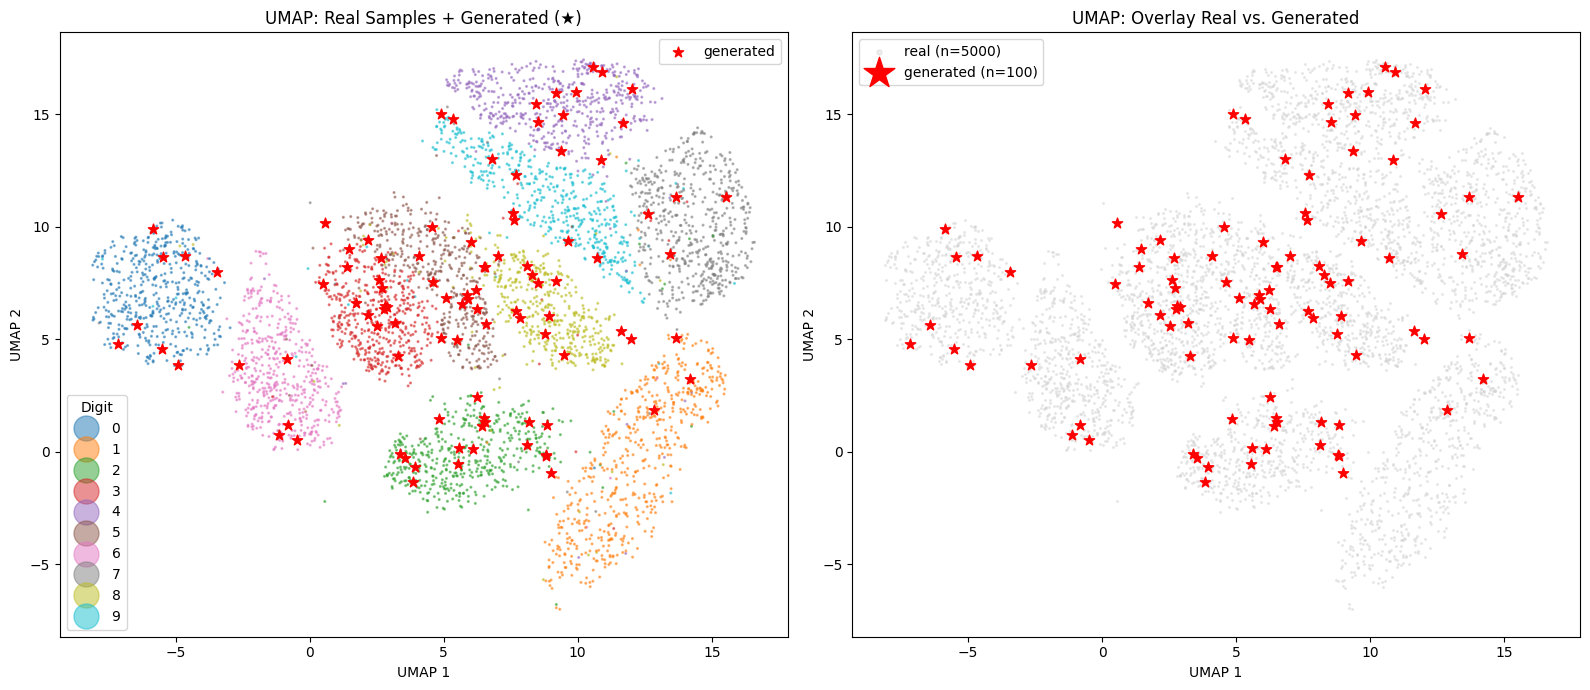

In [47]:
# Umap exploration
# nb of real samples
n_real = 5000

# real flat samples
X_real   = images[:n_real].reshape(n_real, -1).numpy().astype("float32")
L_real   = labels[:n_real].numpy()

# faltten generated data
X_gen = generated_images_cpu.reshape(len(generated_images_cpu), -1).numpy()

# project into learned umap projection
emb_real = reducer.transform(X_real).T
emb_gen  = reducer.transform(X_gen).T  

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# all data
ax = axes[0]
sc = ax.scatter(emb_real[0], emb_real[1], c=L_real, cmap="tab10", s=1.5, alpha=0.5)
legend = ax.legend(*sc.legend_elements(), title="Digit", loc="best", markerscale=3)
ax.add_artist(legend)
ax.scatter(emb_gen[0], emb_gen[1], color="red", s=60, zorder=5, marker="*", label="generated")
ax.legend(loc="upper right")
ax.set_title("UMAP: Real Samples + Generated (★)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

# grey overlay
ax = axes[1]
ax.scatter(emb_real[0], emb_real[1], color="lightgrey", s=1.5, alpha=0.4, label=f"real (n={n_real})")
ax.scatter(emb_gen[0], emb_gen[1], color="red", s=60, zorder=5, marker="*", label=f"generated (n={len(X_gen)})")
ax.legend(markerscale=3)
ax.set_title("UMAP: Overlay Real vs. Generated")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

In [48]:
print("gen std over all samples (per pixel, mean):", X_gen.std(axis=0).mean())
print("real std:", X_real.std(axis=0).mean())
print("sample[0] == sample[1]?", np.allclose(X_gen[0], X_gen[1]))

print("real  min/max/mean/std:", X_real.min(), X_real.max(), X_real.mean(), X_real.std())
print("gen   min/max/mean/std:", X_gen.min(),  X_gen.max(),  X_gen.mean(),  X_gen.std())

gen std over all samples (per pixel, mean): 1.1181703
real std: 0.62591755
sample[0] == sample[1]? False
real  min/max/mean/std: -0.42421296 2.8214867 -0.001550252 0.99818355
gen   min/max/mean/std: -3.966996 5.8952284 0.22750054 1.3054342
